In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import osmnx as ox
import time
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cdist
from shapely.ops import unary_union
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import re

## Объединение координат зданий с данными из [kontikimaps](https://kontikimaps.ru/how-old/cities250/datasets?p=cities250)

In [ ]:
# пути к данным
scores_csv = '../data/interim/400-buildings/facade_damage_scores_lr_4classes-b2.csv'
coords_csv = '../data/interim/400-buildings/402_buildings_addresses_coords.csv'
kontiki_gpk = '../data/interim/spb_4districts_buildings.gpkg'

scores_df = pd.read_csv(scores_csv)
coords_df = pd.read_csv(coords_csv)
kontiki_gdf = gpd.read_file(kontiki_gpk)

In [59]:
# присоединяем координаты к скорам по имени здания
scores_coords_df = scores_df.merge(
    coords_df,
    left_on='building_name',
    right_on='photo_names',
    how='left'
)
scores_coords_df.drop(columns='photo_names', inplace=True)

In [60]:
# Создаём GeoDataFrame из lat/lon
scores_coords_gdf = gpd.GeoDataFrame(
    scores_coords_df,
    geometry=gpd.points_from_xy(scores_coords_df['lon'], scores_coords_df['lat']),
    crs='EPSG:4326'
)

# Перепроецируем в CRS kontikimaps (EPSG:3857)
scores_coords_gdf = scores_coords_gdf.to_crs('EPSG:3857')

In [61]:
# привязываем скоры к полигонам kontikimaps по ближайшему соседу (макс. 50 м)
buildings_gdf = gpd.sjoin_nearest(
    scores_coords_gdf,
    kontiki_gdf[['building_id', 'r_year_int', 'geometry']],
    how='left',
    max_distance=50,  # здания дальше 50 м получат NaN
    distance_col='dist_m'
)
buildings_gdf = buildings_gdf.drop_duplicates(subset='building_name', keep='first')

У зданий отстутствует год постройки в БД от kontikimaps. Впишем его вручную, взяв данные с сайта [citiwalls.ru](citiwalls.ru)

In [62]:
# вручную заполняем год постройки для зданий, отсутствующих в kontikimaps (данные с citiwalls.ru)
manual_years = {
    359: 1881,   # Коломенская улица, 28
    280: 1935,   # Витебская улица, 26
    352: 1897,   # Коломенская улица, 3
    281: 1880,   # Псковская улица, 23
    354: 1882,   # Коломенская улица, 11
}

for building_name, year in manual_years.items():
    buildings_gdf.loc[buildings_gdf['building_name'] == building_name, 'r_year_int'] = year

## Сбор признаков из OSM

In [ ]:
# вычисляем геометрические признаки зданий: центроиды, площадь, периметр, азимут фасада
kontiki_gdf_m = kontiki_gdf.to_crs("EPSG:32637")

def longest_edge_azimuth(geom):
    # азимут длиннейшего ребра полигона в радианах от севера
    if geom is None or geom.is_empty:
        return np.nan
    poly = max(geom.geoms, key=lambda g: g.area) if geom.geom_type == "MultiPolygon" else geom
    coords = list(poly.exterior.coords)
    max_len, azimuth = 0, 0
    for i in range(len(coords) - 1):
        x1, y1 = coords[i][:2]
        x2, y2 = coords[i+1][:2]
        length = ((x2-x1)**2 + (y2-y1)**2) ** 0.5
        if length > max_len:
            max_len = length
            azimuth = np.arctan2(x2 - x1, y2 - y1)
    return azimuth

centroids_wgs = kontiki_gdf_m.geometry.centroid.to_crs("EPSG:4326")
kontiki_gdf["centroid_lat"] = centroids_wgs.y
kontiki_gdf["centroid_lon"] = centroids_wgs.x
kontiki_gdf["area_m2"] = kontiki_gdf_m.geometry.area
kontiki_gdf["perimeter_m"] = kontiki_gdf_m.geometry.length

# sin/cos кодировка азимута
azimuths = kontiki_gdf_m.geometry.apply(longest_edge_azimuth)
kontiki_gdf["facade_azimuth_sin"] = np.sin(azimuths)
kontiki_gdf["facade_azimuth_cos"] = np.cos(azimuths)

# год последней реконструкции: максимальный год из r_years_str
def last_year(s):
    years = [int(y) for y in re.findall(r'\b(1[6-9]\d{2}|20[0-5]\d)\b', str(s))]
    return float(max(years)) if years else np.nan

kontiki_gdf['last_modified_year'] = kontiki_gdf['r_years_str'].apply(last_year)

# количество квартир и флаг жилого здания
kontiki_gdf['living_quarters'] = kontiki_gdf['livingQuarters'].fillna(0)
kontiki_gdf['is_apartment'] = kontiki_gdf['isApartmentBuilding'].fillna(0).astype(int)

Собираем из OSM координаты водоемов и автомобильных дорог для 4 выбранных районов

In [64]:
ox.settings.requests_timeout = 180
ox.settings.max_query_area_size = 50_000_000_000
ox.settings.overpass_url = "https://overpass.kumi.systems/api/interpreter"

target_districts = [
    "Центральный район, Санкт-Петербург",
    "Петроградский район, Санкт-Петербург",
    "Василеостровский район, Санкт-Петербург",
    "Адмиралтейский район, Санкт-Петербург",
]

# скачиваем геометрию водоемов и главных дорог из OSM по каждому району
water_geoms, road_geoms = [], []

for district in target_districts:
    w = ox.features_from_place(district, tags={"natural": ["water"], "waterway": ["river", "canal", "stream"]})
    water_geoms.extend(w[w.geometry.notna()].to_crs("EPSG:32637").geometry.tolist())
    time.sleep(3)

    r = ox.features_from_place(district, tags={"highway": ["primary", "secondary", "trunk", "motorway"]})
    road_geoms.extend(r[r.geometry.notna()].to_crs("EPSG:32637").geometry.tolist())
    time.sleep(3)

water_union = unary_union(water_geoms)
roads_union = unary_union(road_geoms)

Вычисляем расстояния от зданий до водоемов и дорог

In [65]:
# расстояния от центроидов зданий до воды и дорог в метрах
centroids_m = kontiki_gdf_m.geometry.centroid

dist_water = np.array([pt.distance(water_union) for pt in tqdm(centroids_m, desc="до воды")])
dist_road  = np.array([pt.distance(roads_union) for pt in tqdm(centroids_m, desc="до дороги")])

kontiki_gdf["distance_to_water_m"]      = dist_water
kontiki_gdf["distance_to_major_road_m"] = dist_road

до воды:   0%|          | 0/14335 [00:00<?, ?it/s]

до дороги: 100%|██████████| 14335/14335 [00:00<00:00, 16629.82it/s]


Собираем из OSM координаты линий метро и трамвайных путей для 4 выбранных районов

In [ ]:
# скачиваем выходы метро (subway_entrance — точки) и трамвайные/жд пути из OSM
# subway_entrance: всегда точки, однозначно маркируют входы/выходы станций метро
metro_station_geoms, tram_rail_geoms = [], []

for district in target_districts:
    m = ox.features_from_place(district, tags={"railway": "subway_entrance"})
    m_pts = m[m.geometry.geom_type == "Point"]
    metro_station_geoms.extend(m_pts.to_crs("EPSG:32637").geometry.tolist())
    time.sleep(3)

    t = ox.features_from_place(district, tags={"railway": ["tram", "rail", "light_rail"]})
    t_lines = t[t.geometry.geom_type.isin(["LineString", "MultiLineString"])]
    tram_rail_geoms.extend(t_lines.to_crs("EPSG:32637").geometry.tolist())
    time.sleep(3)

metro_union = unary_union(metro_station_geoms)
tram_rail_union = unary_union(tram_rail_geoms)

Вычисляем расстояния

In [ ]:
# расстояния от центроидов зданий до линий метро и трамваев/жд
centroids_m = kontiki_gdf_m.geometry.centroid

dist_metro = np.array([pt.distance(metro_union)     for pt in tqdm(centroids_m, desc="до метро")])
dist_tram_rail = np.array([pt.distance(tram_rail_union) for pt in tqdm(centroids_m, desc="до трамвай/жд")])

kontiki_gdf["distance_to_metro_m"] = dist_metro
kontiki_gdf["distance_to_tram_rail_m"] = dist_tram_rail

до трамвай/жд: 100%|██████████| 14335/14335 [00:00<00:00, 22363.68it/s]


Скачиваем amenity-точки, парки и пешеходные зоны из OSM

In [ ]:
# скачиваем из OSM: amenity-точки, парки, пешеходные зоны
amenity_coords_list, park_geoms, pedestrian_geoms = [], [], []

for district in target_districts:
    a = ox.features_from_place(district, tags={"amenity": True})
    pts = a[a.geometry.geom_type == "Point"].to_crs("EPSG:4326")
    for geom in pts.geometry:
        amenity_coords_list.append((geom.y, geom.x))
    time.sleep(3)

    p = ox.features_from_place(district, tags={"leisure": "park"})
    park_geoms.extend(p[p.geometry.notna()].to_crs("EPSG:32637").geometry.tolist())
    time.sleep(3)

    ped = ox.features_from_place(district, tags={"highway": "pedestrian"})
    pedestrian_geoms.extend(ped[ped.geometry.notna()].to_crs("EPSG:32637").geometry.tolist())
    time.sleep(3)

amenity_coords_arr = np.array(amenity_coords_list)
parks_union = unary_union(park_geoms)
pedestrian_union = unary_union(pedestrian_geoms)
print(f"Amenity: {len(amenity_coords_list)}, парков: {len(park_geoms)}, пеш. зон: {len(pedestrian_geoms)}")

Amenity: 20154, парков: 507, пеш. зон: 38


In [ ]:
# количество amenity в радиусе 300 м (BallTree haversine)
amenity_tree  = BallTree(np.radians(amenity_coords_arr), metric="haversine")
radius_rad = 300 / 6_371_000
centroids_latlon = np.column_stack([kontiki_gdf["centroid_lat"], kontiki_gdf["centroid_lon"]])
counts = amenity_tree.query_radius(np.radians(centroids_latlon), r=radius_rad, count_only=True)
kontiki_gdf["amenity_count_300m"] = counts

# расстояния до парка и пешеходной зоны
dist_park = np.array([pt.distance(parks_union) for pt in tqdm(centroids_m, desc="до парка")])
dist_ped  = np.array([pt.distance(pedestrian_union) for pt in tqdm(centroids_m, desc="до пеш. зоны")])

kontiki_gdf["distance_to_park_m"]       = dist_park
kontiki_gdf["distance_to_pedestrian_m"] = dist_ped

до пеш. зоны: 100%|██████████| 14335/14335 [00:00<00:00, 148314.83it/s]


Повторная сборка финального csv с новыми признаками

In [ ]:
# проверяем пропуски и распределения всех признаков перед сохранением
check_cols = [
    "area_m2", "perimeter_m",
    "r_year_int", "r_floors",
    "last_modified_year", "living_quarters", "is_apartment",
    "distance_to_water_m", "distance_to_major_road_m",
    "distance_to_metro_m", "distance_to_tram_rail_m",
    "amenity_count_300m", "distance_to_park_m", "distance_to_pedestrian_m",
    "r_style",
]

nan_info = pd.DataFrame({
    "NaN": [kontiki_gdf[c].isna().sum() for c in check_cols],
    "NaN%": [f"{kontiki_gdf[c].isna().mean()*100:.1f}%" for c in check_cols],
}, index=check_cols)
print(nan_info.to_string())

num_cols = [c for c in check_cols if c not in ("r_style", "is_apartment")]
print("\n", kontiki_gdf[num_cols].describe().round(1).to_string())

                           NaN   NaN%
area_m2                      0   0.0%
perimeter_m                  0   0.0%
r_year_int                4468  31.2%
r_floors                     0   0.0%
last_modified_year        4462  31.1%
living_quarters              0   0.0%
is_apartment                 0   0.0%
distance_to_water_m          0   0.0%
distance_to_major_road_m     0   0.0%
distance_to_metro_m          0   0.0%
distance_to_tram_rail_m      0   0.0%
amenity_count_300m           0   0.0%
distance_to_park_m           0   0.0%
distance_to_pedestrian_m     0   0.0%
r_style                   9429  65.8%

        area_m2  perimeter_m  r_year_int  r_floors  last_modified_year  living_quarters  distance_to_water_m  distance_to_major_road_m  distance_to_metro_m  distance_to_tram_rail_m  amenity_count_300m  distance_to_park_m  distance_to_pedestrian_m
count  14335.0      14335.0      9867.0   14335.0              9873.0          14335.0              14335.0                   14335.0           

In [71]:
node_features = [
    "building_id", "district_name",
    "centroid_lat", "centroid_lon",
    "area_m2", "perimeter_m",
    "r_year_int", "r_floors",
    "last_modified_year",     
    "distance_to_water_m", "distance_to_major_road_m",
    "distance_to_metro_m", "distance_to_tram_rail_m",
    "amenity_count_300m", "distance_to_park_m", "distance_to_pedestrian_m",
    "r_style",
]

kontiki_gdf[node_features].to_csv("../data/processed/gnn_node_features-b2-08.05.csv", index=False)

# Объединение собранных данных с данными из OSM

In [73]:
# четыре целевых скора повреждений фасада
new_score_cols = [
    'coating_deterioration_score',
    'masonry_degradation_score',
    'moisture_bio_damage_score',
    'vandalism_score',
]

# читаем признаки с диска (контрольная точка после долгого сбора OSM-данных)
gnn_df = pd.read_csv('../data/processed/gnn_node_features-b2-08.05.csv')

In [74]:
# выбираем размеченные здания (те, для которых есть скоры повреждений)
labeled = (
    buildings_gdf[['building_id', 'building_name'] + new_score_cols]
    .dropna(subset=['building_id'])
    .copy()
)
labeled['building_id'] = labeled['building_id'].astype(int)
labeled['is_labeled'] = 1

оказалось, что все дубли - это угловые здания, являющиеся, по сути, разными фасадами одних и тех же зданий.
Не будем их удалять, т.к это довольно типовой случай и интересно посмотреть, что из этого получится.

In [ ]:
# угловые здания имеют несколько фасадов с одним building_id
# для каждого дополнительного фасада создаём синтетический узел с новым ID
dup_bids = labeled[labeled.duplicated(subset='building_id', keep=False)]['building_id'].unique()

gnn_extended = gnn_df[node_features].copy()
gnn_extended['facade_group'] = gnn_extended['building_id']
labeled_fixed = labeled.copy()
max_bid = int(gnn_extended['building_id'].max()) + 1
new_rows = []

for bid in dup_bids:
    for idx in labeled_fixed[labeled_fixed['building_id'] == bid].index[1:]:
        new_row = gnn_extended[gnn_extended['building_id'] == bid].iloc[0].copy()
        new_row['building_id']  = max_bid
        new_row['facade_group'] = bid
        new_rows.append(new_row)
        labeled_fixed.loc[idx, 'building_id'] = max_bid
        max_bid += 1

if new_rows:
    gnn_extended = pd.concat([gnn_extended, pd.DataFrame(new_rows)], ignore_index=True)

labeled_fixed['building_id'] = labeled_fixed['building_id'].astype(int)
gnn_extended['building_id']  = gnn_extended['building_id'].astype(int)

df_nodes = gnn_extended.merge(
    labeled_fixed[['building_id', 'building_name'] + new_score_cols + ['is_labeled']],
    on='building_id', how='left'
)
df_nodes['is_labeled']   = df_nodes['is_labeled'].fillna(0).astype(int)
df_nodes['facade_group'] = df_nodes['facade_group'].fillna(df_nodes['building_id'])

In [ ]:
df = df_nodes.copy()

# нули в этажах - это пропуски, а не реальные нули
df['r_floors'] = df['r_floors'].replace(0, np.nan)

# заполняем пропуски медианой по району, при отсутствии — глобальной медианой
for src_col, dst_col in [('r_year_int', 'year_built'), ('r_floors', 'floors')]:
    district_median = df.groupby('district_name')[src_col].median()
    global_median   = df[src_col].median()
    df[dst_col] = df[src_col].fillna(df['district_name'].map(district_median)).fillna(global_median)

# год последней реконструкции: если неизвестен, берём год постройки
df['last_modified_year'] = df['last_modified_year'].fillna(df['year_built'])

# Построение k-NN графа

In [ ]:
# строим пространственный граф
# расстояния считаем по формуле haversine
k_neighbors = 6
earth_radius = 6_371_000

coords_rad = np.radians(df[["centroid_lat", "centroid_lon"]].values)
tree = BallTree(coords_rad, metric="haversine")


distances, indices = tree.query(coords_rad, k=k_neighbors + 1)
distances_m = distances * earth_radius

# медиана расстояния до k-го соседа
sigma = np.median(distances_m[:, -1])

building_ids = df["building_id"].values
src_list = np.repeat(np.arange(len(df)), k_neighbors)
dst_list  = indices[:, 1:].flatten()   # убираем первый столбец (само здание)
dist_list = distances_m[:, 1:].flatten()

# чем ближе здания, тем больше вес
df_edges = pd.DataFrame({
    "source_building_id": building_ids[src_list],
    "target_building_id": building_ids[dst_list],
    "distance_m": dist_list.round(2),
    "edge_weight": np.exp(-dist_list / sigma).round(6),
})
df_edges.to_csv("../data/processed/graph_edges.csv", index=False)

In [ ]:
# one-hot кодировка района 
district_dummies = pd.get_dummies(df['district_name'], prefix='dist', drop_first=True)
district_cols = district_dummies.columns.tolist()
for col in district_cols:
    df[col] = district_dummies[col].astype(float)

# в исходных данных стили записаны с опечатками и в разном регистре
# схлопываем их к 8 категориям
style_map = {
    'барокко': 'baroque',
    'необарокко': 'baroque',
    'петровское барокко': 'baroque',
    'петровское (раннее) барокко':  'baroque',
    'барокко / классицизм':   'baroque',
    'классицизм': 'classicism',
    'ранний классицизм': 'classicism',
    'неоклассицизм': 'neoclassicism',
    'сталинский неоклассицизм': 'neoclassicism',
    'неоклассицизм (ретроспективизм)': 'neoclassicism',
    'эклектика': 'eclecticism',
    'неоренессанс': 'eclecticism',
    'кирпичный': 'eclecticism',
    'псевдоготика': 'eclecticism',
    'неорусский': 'eclecticism',
    'псевдорусский': 'eclecticism',
    'ретроспективизм': 'eclecticism',
    'византийский': 'eclecticism',
    'модерн': 'art_nouveau',
    'конструктивизм': 'constructivism',
    'конструктивизм, постконструктивизм': 'constructivism',
    'современный': 'modern',
    'рядовая застройка': 'vernacular',
    'рядовая застройка (основной корпус)':'vernacular',
}

def encode_style(s):
    if pd.isna(s):
        return 'unknown'
    return style_map.get(s.strip().lower(), 'unknown')

df['r_style_enc'] = df['r_style'].map(encode_style)

# one-hot кодировка стиля
r_style_dummies = pd.get_dummies(df['r_style_enc'], prefix='style', drop_first=True)
r_style_cols = r_style_dummies.columns.tolist()
for col in r_style_cols:
    df[col] = r_style_dummies[col].astype(float)

print(df['r_style_enc'].value_counts())

# итоговые списки признаков и целевых переменных
feature_cols = [
    "centroid_lat", "centroid_lon",
    "area_m2", "perimeter_m",
    "year_built", "floors",
    "last_modified_year",
    "distance_to_water_m", "distance_to_major_road_m",
    "distance_to_metro_m", "distance_to_tram_rail_m",
    "amenity_count_300m", "distance_to_park_m", "distance_to_pedestrian_m",
    *district_cols,
    *r_style_cols,
]

target_cols = [
    "coating_deterioration_score",
    "masonry_degradation_score",
    "moisture_bio_damage_score",
    "vandalism_score",
]

df.to_csv("../data/processed/gnn_node_features.csv", index=False)

In [ ]:
# нормализуем признаки
x_arr = df[feature_cols].fillna(df[feature_cols].median())
x = torch.tensor(StandardScaler().fit_transform(x_arr.values), dtype=torch.float)

# переводим рёбра из building_id в индексы строк датафрейма
id_to_idx  = {bid: i for i, bid in enumerate(df["building_id"].values)}
src  = [id_to_idx[e] for e in df_edges["source_building_id"]]
dst = [id_to_idx[e] for e in df_edges["target_building_id"]]
edge_index = torch.tensor([src, dst], dtype=torch.long)
edge_attr = torch.tensor(df_edges["edge_weight"].values, dtype=torch.float)

#
y = torch.tensor(df[target_cols].fillna(0).values, dtype=torch.float)
train_mask = torch.tensor(df["is_labeled"].values.astype(bool))

data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr,
            y=y, train_mask=train_mask)
data.feature_names = feature_cols
data.target_names  = target_cols

torch.save(data, "../data/processed/graph_data.pt")

# Построение GNN модели

In [ ]:
# наивный бейзлайн. предсказываем среднее значение по обучающей выборке для всех зданий
labeled_df = df[df['is_labeled'] == 1]
maes = []
for col in target_cols:
    mae = (labeled_df[col] - labeled_df[col].mean()).abs().mean()
    maes.append(mae)
    print(f"{col:35s} naive MAE = {mae:.3f}")
print(f"{'Среднее':35s} naive MAE = {sum(maes)/len(maes):.3f}")

## Проверка индексов Морана

In [ ]:
labeled_nodes = df[df['is_labeled'] == 1].copy().reset_index(drop=True)
coords = labeled_nodes[['centroid_lat', 'centroid_lon']].values
scores = labeled_nodes[target_cols].values
n = len(labeled_nodes)

# матрица попарных расстояний между всеми размеченными зданиями
coords_rad = np.radians(coords)
lat = coords_rad[:, 0]
lon = coords_rad[:, 1]
dlat = lat[:, None] - lat[None, :]
dlon = lon[:, None] - lon[None, :]
a = np.sin(dlat / 2) ** 2 + np.cos(lat[:, None]) * np.cos(lat[None, :]) * np.sin(dlon / 2) ** 2
dist_matrix = 2 * 6_371_000 * np.arcsin(np.sqrt(a))

# чем дальше здания, тем сильнее должны отличаются их скоры
print("Корреляция расстояние vs разница скора")
for i, col in enumerate(target_cols):
    diffs = np.abs(scores[:, i:i+1] - scores[:, i:i+1].T)
    mask = dist_matrix > 0
    corr = np.corrcoef(dist_matrix[mask], diffs[mask])[0, 1]
    print(f"  {col:35s} corr = {corr:+.3f}")

# строим матрицу весов k-NN для индекса Морана
# W[i,j] = 1 если i и j — соседи, иначе 0
tree = BallTree(coords_rad, metric='haversine')
_, knn_idx = tree.query(coords_rad, k=7)  

W = np.zeros((n, n))
for i, neighbors in enumerate(knn_idx):
    for j in neighbors[1:]:
        W[i, j] = 1
# ребро есть, если хотя бы одна из сторон считает другую соседом
W = np.maximum(W, W.T)
W_sum = W.sum()

# E[I]
e_i = -1 / (n - 1)

def moran_i(vals, W, W_sum, n):
    z = vals - vals.mean()
    return (n / W_sum) * (np.sum(W * np.outer(z, z)) / np.sum(z ** 2))

# сравниваем наблюдаемый I с распределением при случайных перестановках
n_perms = 999
rng = np.random.default_rng(42)

for i, col in enumerate(target_cols):
    vals = scores[:, i]
    I_obs   = moran_i(vals, W, W_sum, n)
    I_perms = np.array([moran_i(rng.permutation(vals), W, W_sum, n) for _ in range(n_perms)])
    p_val   = (np.sum(I_perms >= I_obs) + 1) / (n_perms + 1)
    verdict = "кластеризация" if (I_obs > e_i and p_val < 0.05) else \
              "кластеризация слабая" if I_obs > e_i else "дисперсия"
    print(f"  {col:35s} {I_obs:+.4f}  {e_i:.4f}  {p_val:>8.3f}  {verdict}")

### Диагностика: проверяем разнесённость признаково-похожих зданий

In [ ]:
# проверяем гипотезу: если схожие по признакам здания географически близки,
# то пространственный граф и граф схожести дадут похожие рёбра
diag_cols = [
    'area_m2', 'perimeter_m', 'year_built', 'floors', 'last_modified_year',
    'distance_to_water_m', 'distance_to_major_road_m',
    'distance_to_metro_m', 'distance_to_tram_rail_m',
    'amenity_count_300m', 'distance_to_park_m', 'distance_to_pedestrian_m',
]

X_diag = StandardScaler().fit_transform(
    df[diag_cols].fillna(df[diag_cols].median()).values
)

# находим k ближайших соседей в пространстве признаков
k_diag = 8
_, indices_diag = BallTree(X_diag, metric='euclidean').query(X_diag, k=k_diag + 1)

src_idx = np.repeat(np.arange(len(df)), k_diag)
dst_idx = indices_diag[:, 1:].flatten()

# считаем реальное географическое расстояние между признаково-похожими соседями
lat_r = np.radians(df['centroid_lat'].values.astype(float))
lon_r = np.radians(df['centroid_lon'].values.astype(float))
dlat = lat_r[dst_idx] - lat_r[src_idx]
dlon = lon_r[dst_idx] - lon_r[src_idx]
a = np.sin(dlat/2)**2 + np.cos(lat_r[src_idx]) * np.cos(lat_r[dst_idx]) * np.sin(dlon/2)**2
geo_dists = 2 * 6_371_000 * np.arcsin(np.sqrt(a))

print(f"Расстояние между архитектурно похожими соседями:")
print(f"медиана: {np.median(geo_dists):.0f} м")
print(f">1 км: {(geo_dists > 1000).mean():.1%}")
print(f">5 км: {(geo_dists > 5000).mean():.1%}")

## Проверка гипотез о признаках. Итерация 1

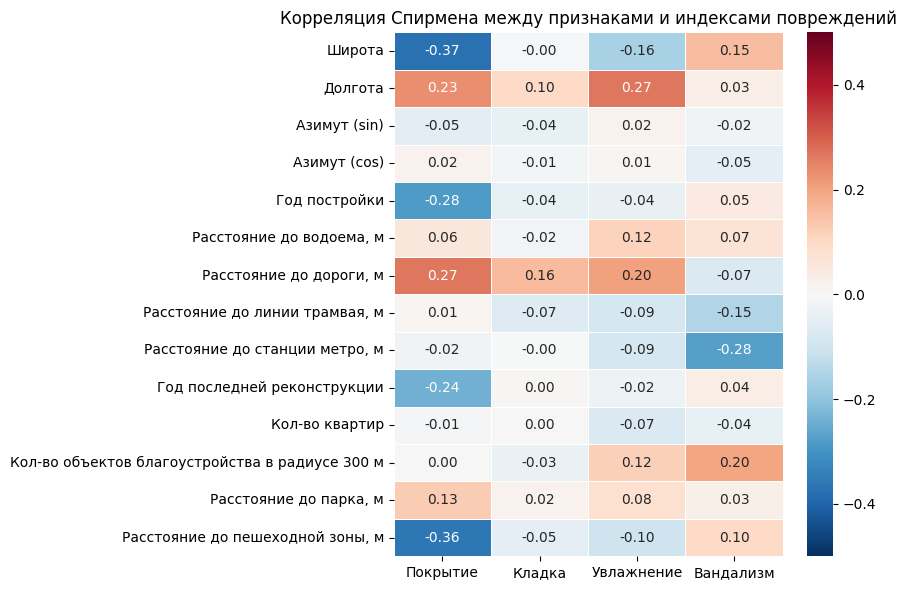

In [ ]:
labeled_nodes = pd.read_csv('../data/processed/gnn_node_features-raw-final.csv', index_col=False)

feature_map = {
    'centroid_lat': 'Широта',
    'centroid_lon': 'Долгота',
    'facade_azimuth_sin': 'Азимут (sin)',
    'facade_azimuth_cos': 'Азимут (cos)',
    'year_built': 'Год постройки',
    'distance_to_water_m': 'Расстояние до водоема, м',
    'distance_to_major_road_m': 'Расстояние до дороги, м',
    'distance_to_tram_rail_m': 'Расстояние до линии трамвая, м',
    'distance_to_metro_m': 'Расстояние до станции метро, м',
    'last_modified_year': 'Год последней реконструкции',
    'living_quarters': 'Кол-во квартир',
    'amenity_count_300m': 'Кол-во объектов благоустройства в радиусе 300 м',
    'distance_to_park_m': 'Расстояние до парка, м',
    'distance_to_pedestrian_m': 'Расстояние до пешеходной зоны, м',
    
}
target_labels = ['Покрытие', 'Кладка', 'Увлажнение', 'Вандализм']
feat_cols = list(feature_map.keys())

corr_matrix = np.zeros((len(feat_cols), len(target_cols)))
pval_matrix = np.zeros_like(corr_matrix)

for i, fc in enumerate(feat_cols):
    for j, tc in enumerate(target_cols):
        r, p = stats.spearmanr(labeled_nodes[fc], labeled_nodes[tc])
        corr_matrix[i, j] = r
        pval_matrix[i, j] = p

corr_df = pd.DataFrame(corr_matrix,
    index=list(feature_map.values()),
    columns=target_labels,
)


annot = np.array([[f"{corr_matrix[i,j]:.2f}"                
                   
                   for j in range(len(target_cols))]
                  for i in range(len(feat_cols))])

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(corr_df, annot=annot, fmt='', cmap='RdBu_r',
            center=0, vmin=-0.5, vmax=0.5, linewidths=0.5, ax=ax)
ax.set_title('Корреляция Спирмена между признаками и индексами повреждений')
plt.tight_layout()
plt.show()


In [ ]:
style_df = labeled_nodes[labeled_nodes['r_style'].notna()].copy()
style_counts = style_df['r_style'].value_counts()
valid_styles = style_counts[style_counts >= 5].index
style_df = style_df[style_df['r_style'].isin(valid_styles)]


print(f"{'Скор':35s}  {'H':>7}  {'p-value':>8}  {'eta²':>6}  Вывод")
for col, label in zip(target_cols, target_labels):
    groups = [g[col].values for _, g in style_df.groupby('r_style')]
    H, p = stats.kruskal(*groups)
    grand_mean = style_df[col].mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    ss_total = ((style_df[col] - grand_mean) ** 2).sum()
    eta2 = ss_between / ss_total
    verdict = "значимо" if p < 0.05 else "незначимо"
    print(f"{col:35s}  {H:7.2f}  {p:8.3f}  {eta2:6.3f}  {verdict}")


Координаты — гипотеза подтверждена, но механизм другой. Моран показывает значимую кластеризацию для всех скоров. Но по тепловой карте работают именно широта и долгота как таковые (−0.37 и +0.27), а не близость к соседям. Это эффект района. Адмиралтейский и Петроградский расположены на разных широтах и имеют разный уровень обслуживания зданий, координаты кодируют не пространственное соседство, а принадлежность к кварталу.

Азимут — гипотеза не подтверждена. Ни sin, ни cos не дают значимой корреляции ни с одним скором. Признак можно убрать из модели.

Год постройки — подтверждён только для отделкия (−0.28): чем старше здание, тем хуже состояние отделки. Для остальных скоров эффекта нет — вероятно, кладка, увлажнение и вандализм больше зависят от обслуживания, чем от возраста.

Расстояние до воды — слабо и в обратном направлении (+0.12 с увлажнением). Скорее всего, набережные — это престижные и хорошо обслуживаемые адреса, а увлажнение выше у зданий в глубине кварталов.

Расстояния до дороги, трамвая, метро — вибрационная гипотеза не подтверждена. Вместо этого чем дальше от дороги = хуже состояние. Видимо, фасады вдоль главных проспектов ремонтируют чаще, потому что они на виду. Трамвай и метро дают значимую отрицательную корреляцию с вандализмом.

Архитектурный стиль — работает для отделки (eta=0.10). Для кладки, увлажнения и вандализма стиль неважен

### Новые признаки: жилое/нежилое и район

In [ ]:
if 'is_apartment' in labeled_nodes.columns: 
    print(f"  {'Скор':35s}  {'H':>6}  {'p-value':>8}  {'eta2':>6}  Вывод")
    for col, label in zip(target_cols, target_labels):
        g0 = labeled_nodes[labeled_nodes['is_apartment'] == 0][col].dropna()
        g1 = labeled_nodes[labeled_nodes['is_apartment'] == 1][col].dropna()
        if len(g0) < 2 or len(g1) < 2:
            # недостаточно данных
            continue
        H, p = stats.kruskal(g0, g1)
        grand = labeled_nodes[col].mean()
        ss_b  = len(g0)*(g0.mean()-grand)**2 + len(g1)*(g1.mean()-grand)**2
        ss_t  = ((labeled_nodes[col] - grand)**2).sum()
        eta2  = ss_b / ss_t
        verdict = "значимо *" if p < 0.05 else "незначимо"
        print(f"  {col:35s}  {H:6.2f}  {p:8.3f}  {eta2:6.3f}  {verdict}")

    # медианы по группам  
    print(f"  {'':35s}", "  ".join(f"{l:>12}" for l in target_labels))
    for apt, label in [(0, "нежилое/неизвестно"), (1, "жилое")]:
        g = labeled_nodes[labeled_nodes['is_apartment'] == apt]
        medians = "  ".join(f"{g[c].median():12.3f}" for c in target_cols)
        print(f"  {label:35s}  {medians}")

In [ ]:
if 'district_name' in labeled_nodes.columns: 
    print(f"  {'Скор':35s}  {'H':>6}  {'p-value':>8}  {'eta2':>6}  Вывод")
    for col, label in zip(target_cols, target_labels):
        groups = [g[col].dropna().values
                  for _, g in labeled_nodes.groupby('district_name')
                  if len(g[col].dropna()) >= 2]
        H, p = stats.kruskal(*groups)
        grand = labeled_nodes[col].mean()
        ss_b  = sum(len(g)*(g.mean()-grand)**2 for g in groups)
        ss_t  = ((labeled_nodes[col] - grand)**2).sum()
        eta2  = ss_b / ss_t
        verdict = "значимо" if p < 0.05 else "незначимо"
        print(f"  {col:35s}  {H:6.2f}  {p:8.3f}  {eta2:6.3f}  {verdict}")

    # медианы по районам
    for d, g in labeled_nodes.groupby('district_name'):
        print(f"  {d:40s}  n={len(g):3d}  медиана={g['coating_deterioration_score'].median():.3f}")